In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

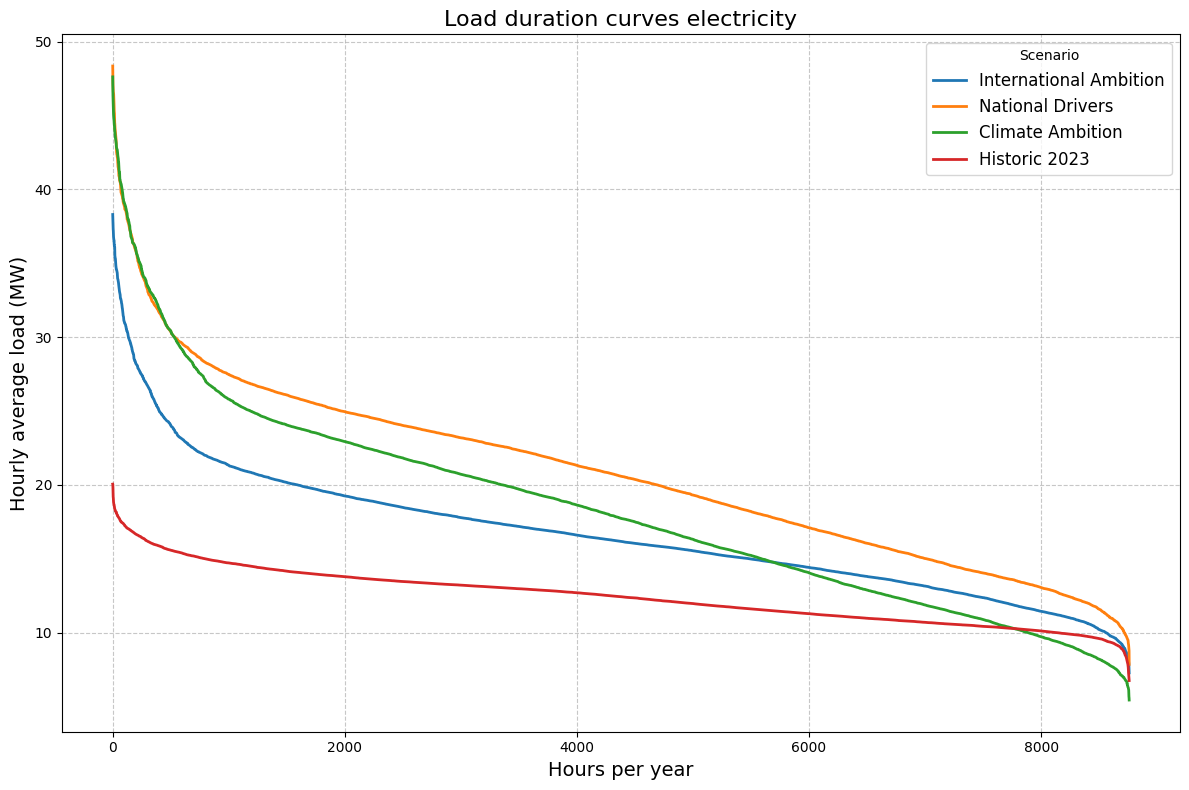

In [15]:
files = {
    "International Ambition": "ip2024_ia_2030/ip2024_international_ambition.csv",
    "National Drivers": "ip2024_nd_2030/ip2024_national_drivers.csv",
    "Climate Ambition": "ip2024_ka_2030/ip2024_klimaat_ambitie.csv",
    "Historic 2023": "historic_2023/demand_elc.csv"}

sorted_loads = {}

for scenario, file_path in files.items():
    data = pd.read_csv(file_path, parse_dates=["time"])
    
    data = data.sort_values("time")
    
    data["total_demand"] = data.drop(columns=["time"]).sum(axis=1).abs()  
    
    sorted_loads[scenario] = data["total_demand"].sort_values(ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 8))

for scenario, sorted_values in sorted_loads.items():
    plt.plot(
        sorted_values.values,
        label=scenario,
        linewidth=2
    )

# Plot
plt.xlabel("Hours per year", fontsize=14)
plt.ylabel("Hourly average load (MW)", fontsize=14)
plt.title("Load duration curves electricity", fontsize=16)
plt.legend(title="Scenario", fontsize=12, loc="upper right")
plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig("Load Duration Curves electricity.pdf", dpi=300, bbox_inches="tight")
plt.show()


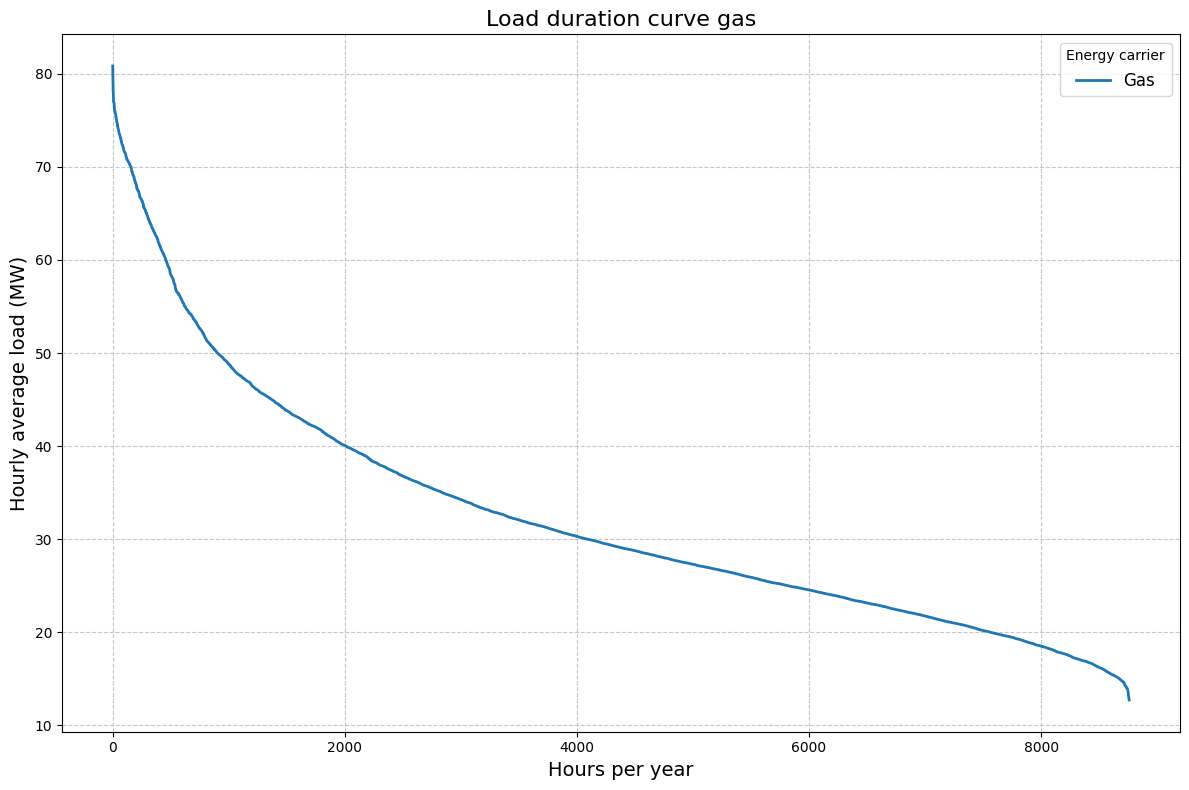

In [17]:
files = {
    "Gas": "historic_2023/demand_gas.csv",
}

sorted_loads = {}

for scenario, file_path in files.items():
    data = pd.read_csv(file_path, parse_dates=["time"])
    data = data.sort_values("time")
    
    data["total_demand"] = data.drop(columns=["time"]).sum(axis=1).abs()  # Make values positive
    
    sorted_loads[scenario] = data["total_demand"].sort_values(ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 8))

for scenario, sorted_values in sorted_loads.items():
    plt.plot(
        sorted_values.values,
        label=scenario,
        linewidth=2
    )

plt.xlabel("Hours per year", fontsize=14)
plt.ylabel("Hourly average load (MW)", fontsize=14)
plt.title("Load duration curve gas", fontsize=16)
plt.legend(title="Energy carrier", fontsize=12, loc="upper right")
plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig("Load duration curve gas 2023.pdf", dpi=300, bbox_inches="tight")
plt.show()